<a href="https://colab.research.google.com/github/AhmedXAlDeeb/Prescriptions-OCR/blob/main/trocr_w.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# prompt: connect to google drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install jiwer

#Training 1


In [ ]:
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import pandas as pd
from tqdm.auto import tqdm
import jiwer
import numpy as np

def compute_cer(predictions, labels):
    total_cer = 0
    for pred, label in zip(predictions, labels):
        pred = pred.lower()
        label = label.lower()

        distance = jiwer.compute_measures(label, pred)['substitutions'] + \
                  jiwer.compute_measures(label, pred)['deletions'] + \
                  jiwer.compute_measures(label, pred)['insertions']

        total_chars = len(label)
        if total_chars > 0:
            total_cer += distance / total_chars

    return total_cer / len(predictions)

def compute_wer(predictions, labels):
    return jiwer.wer(labels, predictions)

class OCRDataset(Dataset):
    def __init__(self, image_dir, excel_file, processor):
        self.image_dir = image_dir
        self.processor = processor

        try:
            df = pd.read_excel(excel_file)
            if len(df.columns) < 2:
                raise ValueError("Excel file must have at least 2 columns")

            self.examples = []
            for _, row in tqdm(df.iterrows(), total=len(df), desc="Loading dataset"):
                label = str(row[0])
                image_path = str(row[1]) + ".jpg"

                if os.path.exists(os.path.join(image_dir, image_path)):
                    self.examples.append((image_path, label))
                else:
                    print(f"Warning: Image {image_path} not found")

            if not self.examples:
                raise Exception("No valid examples found in the Excel file")

            print(f"Successfully loaded {len(self.examples)} examples")

        except Exception as e:
            raise Exception(f"Error reading Excel file: {str(e)}")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        image_path, text = self.examples[idx]
        try:
            image = Image.open(os.path.join(self.image_dir, image_path)).convert('RGB')
        except Exception as e:
            print(f"Error loading image {image_path}: {str(e)}")
            if len(self.examples) > 1:
                return self.__getitem__((idx + 1) % len(self.examples))
            raise

        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        labels = self.processor.tokenizer(text,
                                        padding="max_length",
                                        max_length=128,
                                        truncation=True,
                                        return_tensors="pt").input_ids

        return {
            'pixel_values': pixel_values.squeeze(),
            'labels': labels.squeeze(),
            'text': text
        }

# Previous imports remain the same...

def train_model(model, train_dataloader, val_dataloader, processor, device, num_epochs=20, learning_rate=5e-5):
    model.train()
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    best_val_cer = float('inf')

    # Create progress bar for epochs
    epoch_pbar = tqdm(range(num_epochs), desc="Training", position=0)

    for epoch in epoch_pbar:
        # Training loop
        model.train()
        total_loss = 0
        # Create progress bar for batches
        batch_pbar = tqdm(train_dataloader, desc=f"Epoch {epoch}", position=1, leave=False)

        for batch_idx, batch in enumerate(batch_pbar):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Evaluate and update metrics every 100 batches
            if batch_idx % 100 == 0:
                model.eval()
                with torch.no_grad():
                    # Generate predictions for current batch
                    generated_ids = model.generate(pixel_values)
                    pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
                    label_texts = batch['text']

                    # Calculate batch metrics
                    batch_cer = compute_cer(pred_texts, label_texts)
                    batch_wer = compute_wer(label_texts, pred_texts)

                    # Update batch progress bar with all metrics
                    batch_pbar.set_postfix({
                        'loss': f"{loss.item():.4f}",
                        'CER': f"{batch_cer:.4f}",
                        'WER': f"{batch_wer:.4f}"
                    })
                model.train()
            else:
                # Regular loss update
                batch_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        # Calculate average training loss
        avg_train_loss = total_loss / len(train_dataloader)

        # Validation loop
        val_metrics = evaluate_model(model, val_dataloader, processor, device)

        # Update epoch progress bar with all metrics
        metrics_str = (f"train_loss: {avg_train_loss:.4f}, "
                      f"val_loss: {val_metrics['loss']:.4f}, "
                      f"val_CER: {val_metrics['cer']:.4f}, "
                      f"val_WER: {val_metrics['wer']:.4f}")
        epoch_pbar.write(f"Epoch {epoch} - {metrics_str}")

        # Save best model
        if val_metrics['cer'] < best_val_cer:
            best_val_cer = val_metrics['cer']
            model.save_pretrained("/content/drive/MyDrive/trocr_finetuned_best")
            epoch_pbar.write(f"Saved new best model with CER: {best_val_cer:.4f}")

        batch_pbar.close()

def evaluate_model(model, dataloader, processor, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    eval_pbar = tqdm(dataloader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for batch in eval_pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            # Get loss
            outputs = model(pixel_values=pixel_values, labels=labels)
            total_loss += outputs.loss.item()

            # Generate predictions
            generated_ids = model.generate(pixel_values)
            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            label_texts = batch['text']

            all_predictions.extend(pred_texts)
            all_labels.extend(label_texts)

            # Calculate and show running metrics
            current_cer = compute_cer(pred_texts, label_texts)
            current_wer = compute_wer(label_texts, pred_texts)
            eval_pbar.set_postfix({
                'loss': f"{outputs.loss.item():.4f}",
                'CER': f"{current_cer:.4f}",
                'WER': f"{current_wer:.4f}"
            })

    # Calculate final metrics
    final_cer = compute_cer(all_predictions, all_labels)
    final_wer = compute_wer(all_labels, all_predictions)
    avg_loss = total_loss / len(dataloader)

    return {
        'loss': avg_loss,
        'cer': final_cer,
        'wer': final_wer
    }

# Rest of the code remains the same...
def main():
    # Install required packages
    try:
        import pandas as pd
        from tqdm.auto import tqdm
        import jiwer
    except ImportError:
        !pip install pandas openpyxl tqdm jiwer
        import pandas as pd
        from tqdm.auto import tqdm
        import jiwer

    print("Loading model and processor...")
    processor = TrOCRProcessor.from_pretrained('/content/drive/MyDrive/trocr_finetuned_final')
    model = VisionEncoderDecoderModel.from_pretrained('/content/drive/MyDrive/trocr_finetuned_final')
    # set special tokens used for creating the decoder_input_ids from the labels
    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.config.pad_token_id = processor.tokenizer.pad_token_id
    # make sure vocab size is set correctly
    model.config.vocab_size = model.config.decoder.vocab_size

    # set beam search parameters
    model.config.eos_token_id = processor.tokenizer.sep_token_id
    model.config.max_length = 128
    model.config.early_stopping = True
    model.config.no_repeat_ngram_size = 3
    model.config.length_penalty = 2.0
    model.config.num_beams = 4
    image_dir = "/content/drive/MyDrive/Machathon_Prescription_Digtalization_6.00/Train_Data_Phase1"  # Update this
    excel_file = "/content/drive/MyDrive/Machathon_Prescription_Digtalization_6.00/Train.xlsx"  # Update this

    try:
        full_dataset = OCRDataset(image_dir, excel_file, processor)

        # Split dataset
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = random_split(
            full_dataset,
            [train_size, val_size],
            generator=torch.Generator().manual_seed(42)
        )

        print(f"Training set size: {len(train_dataset)}")
        print(f"Validation set size: {len(val_dataset)}")

    except Exception as e:
        print(f"Error creating dataset: {str(e)}")
        return

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=8
    )

    val_dataloader = DataLoader(
        val_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=8
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    try:
        train_model(model, train_dataloader, val_dataloader, processor, device)

        print("Saving final model...")
        output_dir = "/content/drive/MyDrive/trocr_finetuned_final"
        model.save_pretrained(output_dir)
        processor.save_pretrained(output_dir)
        print(f"Final model saved to {output_dir}")
    except Exception as e:
        print(f"Error during training: {str(e)}")

if __name__ == "__main__":
    main()

Loading model and processor...


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

Loading dataset:   0%|          | 0/623 [00:00<?, ?it/s]

<ipython-input-4-f64ad0bce23b>:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = str(row[0])
<ipython-input-4-f64ad0bce23b>:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_path = str(row[1]) + ".jpg"


Successfully loaded 617 examples
Training set size: 493
Validation set size: 124
Using device: cuda


...

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 18 - train_loss: 0.1119, val_loss: 0.2280, val_CER: 0.1857, val_WER: 1.1881


Epoch 19:   0%|          | 0/62 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 19 - train_loss: 0.1054, val_loss: 0.2348, val_CER: 0.1936, val_WER: 1.1034
Saving final model...
Final model saved to /content/drive/MyDrive/trocr_finetuned_final


#Continue training with better handling for arabic

In [ ]:
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import pandas as pd
from tqdm.auto import tqdm
import jiwer
import numpy as np
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler

def normalize_arabic_text(text):
    arabic_numbers = '٠١٢٣٤٥٦٧٨٩'
    english_numbers = '0123456789'
    trans_table = str.maketrans(arabic_numbers, english_numbers)

    # Normalize Arabic text
    text = text.replace('أ', 'ا')
    text = text.replace('إ', 'ا')
    text = text.replace('آ', 'ا')
    text = text.replace('ة', 'ه')
    text = text.replace('ى', 'ي')

    # Standardize spaces around punctuation
    text = text.replace(' ,', ',')
    text = text.replace(' ،', '،')

    return text

def compute_cer(predictions, labels):
    total_cer = 0
    for pred, label in zip(predictions, labels):
        pred = normalize_arabic_text(pred.lower())
        label = normalize_arabic_text(label.lower())

        distance = jiwer.compute_measures(label, pred)['substitutions'] + \
                  jiwer.compute_measures(label, pred)['deletions'] + \
                  jiwer.compute_measures(label, pred)['insertions']

        total_chars = len(label)
        if total_chars > 0:
            total_cer += distance / total_chars

    return total_cer / len(predictions)

def compute_cer_batch(predictions, labels, batch_size=32):
    """Compute CER in batches to avoid memory issues"""
    total_cer = 0
    for i in range(0, len(predictions), batch_size):
        batch_preds = predictions[i:i + batch_size]
        batch_labels = labels[i:i + batch_size]

        batch_cer = compute_cer(batch_preds, batch_labels)
        total_cer += batch_cer * len(batch_preds)

    return total_cer / len(predictions)

def compute_wer(predictions, labels):
    normalized_preds = [normalize_arabic_text(p.lower()) for p in predictions]
    normalized_labels = [normalize_arabic_text(l.lower()) for l in labels]
    return jiwer.wer(normalized_labels, normalized_preds)

class OCRDataset(Dataset):
    def __init__(self, image_dir, excel_file, processor, is_training=True):
        self.image_dir = image_dir
        self.processor = processor
        self.is_training = is_training

        self.augmentation = transforms.Compose([
            transforms.RandomRotation(2),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.02, 0.02), scale=(0.98, 1.02))
        ]) if is_training else None

        try:
            df = pd.read_excel(excel_file)
            if len(df.columns) < 2:
                raise ValueError("Excel file must have at least 2 columns")

            self.examples = []
            for _, row in tqdm(df.iterrows(), total=len(df), desc="Loading dataset"):
                label = str(row[0])
                image_path = str(row[1]) + ".jpg"

                if os.path.exists(os.path.join(image_dir, image_path)):
                    self.examples.append((image_path, label))
                else:
                    print(f"Warning: Image {image_path} not found")

            if not self.examples:
                raise Exception("No valid examples found in the Excel file")

            print(f"Successfully loaded {len(self.examples)} examples")

        except Exception as e:
            raise Exception(f"Error reading Excel file: {str(e)}")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        image_path, text = self.examples[idx]
        text = normalize_arabic_text(text)

        try:
            image = Image.open(os.path.join(self.image_dir, image_path)).convert('RGB')
            if self.is_training and self.augmentation:
                image = self.augmentation(image)
        except Exception as e:
            print(f"Error loading image {image_path}: {str(e)}")
            if len(self.examples) > 1:
                return self.__getitem__((idx + 1) % len(self.examples))
            raise

        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        labels = self.processor.tokenizer(text,
                                        padding="max_length",
                                        max_length=128,
                                        truncation=True,
                                        return_tensors="pt").input_ids

        return {
            'pixel_values': pixel_values.squeeze(),
            'labels': labels.squeeze(),
            'text': text
        }

def configure_model(model, processor):
    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.config.pad_token_id = processor.tokenizer.pad_token_id
    model.config.vocab_size = model.config.decoder.vocab_size

    model.config.eos_token_id = processor.tokenizer.sep_token_id
    model.config.max_length = 128
    model.config.early_stopping = True
    model.config.no_repeat_ngram_size = 3
    model.config.length_penalty = 2.0
    model.config.num_beams = 4

    return model

def save_checkpoint(model, optimizer, epoch, best_val_cer, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_cer': best_val_cer
    }
    torch.save(checkpoint, filename)

def load_checkpoint(filename):
    return torch.load(filename)

def evaluate_model(model, dataloader, processor, device, max_eval_samples=None):
    """
    Optimized evaluation function
    max_eval_samples: if set, only evaluates on a subset of validation data
    """
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    # If max_eval_samples is set, calculate how many batches to evaluate
    num_batches = len(dataloader) if max_eval_samples is None else \
                 min(len(dataloader), max_eval_samples // dataloader.batch_size + 1)

    eval_pbar = tqdm(enumerate(dataloader), total=num_batches, desc="Evaluating", leave=False)

    with torch.no_grad():
        for batch_idx, batch in eval_pbar:
            if max_eval_samples is not None and batch_idx >= num_batches:
                break

            # Move data to GPU in one go
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass with mixed precision
            with autocast():
                outputs = model(pixel_values=pixel_values, labels=labels)
                loss = outputs.loss

            total_loss += loss.item()

            # Generate predictions for entire batch at once
            generated_ids = model.generate(
                pixel_values,
                max_length=128,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                length_penalty=2.0
            )

            # Batch decode predictions
            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            label_texts = batch['text']

            all_predictions.extend(pred_texts)
            all_labels.extend(label_texts)

            # Update progress bar less frequently
            if batch_idx % 5 == 0:
                current_cer = compute_cer(pred_texts, label_texts)
                current_wer = compute_wer(label_texts, pred_texts)
                eval_pbar.set_postfix({
                    'loss': f"{loss.item():.4f}",
                    'CER': f"{current_cer:.4f}",
                    'WER': f"{current_wer:.4f}"
                })

    # Compute final metrics
    final_cer = compute_cer(all_predictions, all_labels)
    final_wer = compute_wer(all_labels, all_predictions)
    avg_loss = total_loss / num_batches

    return {
        'loss': avg_loss,
        'cer': final_cer,
        'wer': final_wer
    }

def train_model(model, train_dataloader, val_dataloader, processor, device,
                num_epochs=30, learning_rate=5e-5, start_epoch=0, best_val_cer=float('inf'),
                validate_every=1, max_eval_samples=None):
    """
    Modified training loop with optimized validation
    validate_every: perform validation every N epochs
    max_eval_samples: number of samples to use for validation during training
    """
    model.train()
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    num_training_steps = len(train_dataloader) * num_epochs
    num_warmup_steps = num_training_steps // 10
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    scaler = GradScaler()
    epoch_pbar = tqdm(range(start_epoch, start_epoch + num_epochs), desc="Training", position=0)

    for epoch in epoch_pbar:
        model.train()
        total_loss = 0
        batch_pbar = tqdm(train_dataloader, desc=f"Epoch {epoch}", position=1, leave=False)

        for batch_idx, batch in enumerate(batch_pbar):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            with autocast():
                outputs = model(pixel_values=pixel_values, labels=labels)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

            total_loss += loss.item()

            # Reduce frequency of batch evaluation
            if batch_idx % 200 == 0:
                batch_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_train_loss = total_loss / len(train_dataloader)

        # Validate only every N epochs
        if (epoch + 1) % validate_every == 0:
            val_metrics = evaluate_model(model, val_dataloader, processor, device, max_eval_samples)

            metrics_str = (f"train_loss: {avg_train_loss:.4f}, "
                         f"val_loss: {val_metrics['loss']:.4f}, "
                         f"val_CER: {val_metrics['cer']:.4f}, "
                         f"val_WER: {val_metrics['wer']:.4f}")
            epoch_pbar.write(f"Epoch {epoch} - {metrics_str}")
            os.makedirs("/content/drive/MyDrive/trocr_checkpoints", exist_ok=True)
            # Save checkpoint
            checkpoint_path = f"/content/drive/MyDrive/trocr_checkpoints/checkpoint_epoch_{epoch}.pt"
            save_checkpoint(model, optimizer, epoch, val_metrics['cer'], checkpoint_path)

            if val_metrics['cer'] < best_val_cer:
                best_val_cer = val_metrics['cer']
                model.save_pretrained("/content/drive/MyDrive/trocr_finetuned_best")
                epoch_pbar.write(f"Saved new best model with CER: {best_val_cer:.4f}")
        else:
            epoch_pbar.write(f"Epoch {epoch} - train_loss: {avg_train_loss:.4f}")

        batch_pbar.close()

def continue_training():
    # Load the saved model and processor
    saved_model_path = "/content/drive/MyDrive/trocr_finetuned_final"
    checkpoint_path = "/content/drive/MyDrive/trocr_checkpoints/checkpoint_epoch_19.pt"

    processor = TrOCRProcessor.from_pretrained(saved_model_path)
    model = VisionEncoderDecoderModel.from_pretrained(saved_model_path)
    model = configure_model(model, processor)

    # Load checkpoint if exists
    if os.path.exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_cer = checkpoint['best_val_cer']
    else:
        start_epoch = 0
        best_val_cer = float('inf')

    # Set up dataset and dataloaders
    image_dir = "/content/drive/MyDrive/Machathon_Prescription_Digtalization_6.00/Train_Data_Phase1"
    excel_file = "/content/drive/MyDrive/Machathon_Prescription_Digtalization_6.00/Train.xlsx"

    full_dataset = OCRDataset(image_dir, excel_file, processor)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=8
    )

    val_dataloader = DataLoader(
        val_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=8
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Continue training with optimized validation
    train_model(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        processor=processor,
        device=device,
        num_epochs=30,
        learning_rate=1e-5,
        start_epoch=start_epoch,
        best_val_cer=best_val_cer,
        validate_every=2,  # Validate every 2 epochs
        max_eval_samples=1000  # Use only 1000 samples for validation during training
    )

if __name__ == "__main__":
    continue_training()

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

Loading dataset:   0%|          | 0/623 [00:00<?, ?it/s]

<ipython-input-11-f37327cbdc57>:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = str(row[0])
<ipython-input-11-f37327cbdc57>:84: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_path = str(row[1]) + ".jpg"


Successfully loaded 617 examples


<ipython-input-11-f37327cbdc57>:245: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


...

Epoch 28:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch 28 - train_loss: 0.0304


Epoch 29:   0%|          | 0/62 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 29 - train_loss: 0.0293, val_loss: 0.2892, val_CER: 0.1778, val_WER: 1.0434


In [ ]:
from google.colab import runtime
runtime.unassign()


#Inference

In [ ]:
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import os

def load_model(model_path):
    """
    Load the fine-tuned TrOCR model and processor
    """
    processor = TrOCRProcessor.from_pretrained("/content/drive/MyDrive/trocr_finetuned_final")
    model = VisionEncoderDecoderModel.from_pretrained(model_path)
    return processor, model

def predict_text(image_path, processor, model, device='cuda'):
    """
    Predict text from a single image
    """
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    pixel_values = processor(image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    # Generate predictions
    model.to(device)
    model.eval()

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
        predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return predicted_text

def batch_predict(image_folder, processor, model, device='cuda', batch_size=4):
    """
    Predict text from a folder of images in batches
    """
    results = {}
    images = []
    image_paths = []

    # Get all image files
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_files = [f for f in os.listdir(image_folder)
                   if f.lower().endswith(valid_extensions)]

    model.to(device)
    model.eval()

    for i, image_file in enumerate(image_files):
        image_path = os.path.join(image_folder, image_file)
        image = Image.open(image_path).convert('RGB')
        images.append(image)
        image_paths.append(image_path)

        # Process when batch is full or at the end
        if len(images) == batch_size or i == len(image_files) - 1:
            # Preprocess batch
            pixel_values = processor(images, return_tensors="pt").pixel_values
            pixel_values = pixel_values.to(device)

            # Generate predictions
            with torch.no_grad():
                generated_ids = model.generate(pixel_values)
                predicted_texts = processor.batch_decode(generated_ids,
                                                       skip_special_tokens=True)

            # Store results
            for path, text in zip(image_paths, predicted_texts):
                results[path] = text

            # Clear lists for next batch
            images = []
            image_paths = []

    return results

# Example usage
def main():
    # Load model and processor
    model_path = "/content/drive/MyDrive/trocr_finetuned_final"  # or use trocr_finetuned_best
    processor, model = load_model(model_path)

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Single image prediction
    image_path = "/content/drive/MyDrive/Machathon_Prescription_Digtalization_6.00/Train_Data_Phase1/prescription_Gyne_538.jpg"
    predicted_text = predict_text(image_path, processor, model, device)
    print(f"Predicted text: {predicted_text}")

    # # Batch prediction for a folder of images
    # image_folder = "path/to/your/image/folder"
    # results = batch_predict(image_folder, processor, model, device)

    # # Print results
    # print("\nBatch Prediction Results:")
    # for path, text in results.items():
    #     print(f"Image: {os.path.basename(path)}")
    #     print(f"Predicted Text: {text}\n")

if __name__ == "__main__":
    main()

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

Using device: cuda
Predicted text: Vitamin D  Every week , كبريتات الزنك  After meals , Dexamethasone  Before meals , باراسيتامول  Twice daily


#Training 2


In [ ]:
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import cv2
from PIL import Image, ImageOps, ImageEnhance
import os
from torch.cuda.amp import autocast
import pandas as pd
from tqdm.auto import tqdm
import jiwer
import numpy as np
import re
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import get_linear_schedule_with_warmup

def normalize_arabic_text(text):
    """
    Normalize Arabic text and maintain English words
    """
    # Normalize Arabic numbers to Hindi numbers
    arabic_numbers = '٠١٢٣٤٥٦٧٨٩'
    hindi_numbers = '0123456789'
    trans_table = str.maketrans(arabic_numbers, hindi_numbers)

    # Normalize Arabic text
    text = text.replace('أ', 'ا')
    text = text.replace('إ', 'ا')
    text = text.replace('آ', 'ا')
    text = text.replace('ة', 'ه')
    text = text.replace('ى', 'ي')

    # Standardize spaces around punctuation
    text = text.replace(' ,', ',')
    text = text.replace(' ،', '،')

    # Ensure consistent spacing around English words
    text = re.sub(r'([a-zA-Z]+)', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


class ImagePreprocessor:
    def __init__(self, target_size=(384, 384)):
        self.target_size = target_size

    def enhance_contrast(self, image):
        """Enhance image contrast"""
        enhancer = ImageEnhance.Contrast(image)
        return enhancer.enhance(1.5)

    def denoise(self, image):
        """Remove noise from image"""
        img_array = np.array(image)
        denoised = cv2.fastNlMeansDenoisingColored(img_array, None, 10, 10, 7, 21)
        return Image.fromarray(denoised)

    def remove_background(self, image):
        """Remove background using adaptive thresholding"""
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

        binary = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11, 2
        )

        kernel = np.ones((2,2), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        result = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(result)

    def deskew(self, image):
        """Deskew image"""
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

        coords = np.column_stack(np.where(gray > 0))
        angle = cv2.minAreaRect(coords)[-1]

        if angle < -45:
            angle = 90 + angle

        (h, w) = img_array.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(img_array, M, (w, h),
                                flags=cv2.INTER_CUBIC,
                                borderMode=cv2.BORDER_REPLICATE)

        return Image.fromarray(rotated)

class CroppedHandwrittenDataset(Dataset):
    def __init__(self, crops_dir, excel_file, processor, augment=True):
        self.crops_dir = crops_dir
        self.processor = processor
        self.preprocessor = ImagePreprocessor()

        # Define augmentation transforms
        if augment:
            self.augmentation = transforms.Compose([
                transforms.RandomApply([
                    transforms.ColorJitter(brightness=0.2,
                                        contrast=0.2,
                                        saturation=0.1,
                                        hue=0.1)
                ], p=0.5),
                transforms.RandomApply([
                    transforms.GaussianBlur(kernel_size=3)
                ], p=0.2),
                transforms.RandomRotation(degrees=2),
                transforms.RandomAffine(
                    degrees=0,
                    translate=(0.02, 0.02),
                    scale=(0.98, 1.02),
                    shear=2
                )
            ])
        else:
            self.augmentation = None

        # Read excel file
        df = pd.read_excel(excel_file)

        self.examples = []
        for _, row in tqdm(df.iterrows(), desc="Loading dataset"):
            label = str(row[0])
            original_image = str(row[1]) + ".jpg"

            # Normalize the label
            label = normalize_arabic_text(label)

            crop_filename = f"crop_{original_image}"
            crop_path = os.path.join(crops_dir, crop_filename)

            if os.path.exists(crop_path):
                self.examples.append((crop_path, label))

        print(f"Found {len(self.examples)} valid examples")

    def preprocess_image(self, image):
        """Apply preprocessing pipeline"""
        # Apply preprocessing steps
        # image = self.preprocessor.enhance_contrast(image)
        # image = self.preprocessor.denoise(image)
        image = self.preprocessor.remove_background(image)
        # image = self.preprocessor.deskew(image)

        # Apply augmentation if enabled
        if self.augmentation is not None:
            image = self.augmentation(image)

        return image

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        image_path, text = self.examples[idx]

        try:
            # Load and preprocess image
            image = Image.open(image_path).convert('RGB')
            image = self.preprocess_image(image)

            # Process image and text
            pixel_values = self.processor(image, return_tensors="pt").pixel_values
            labels = self.processor.tokenizer(text,
                                           padding="max_length",
                                           max_length=128,
                                           truncation=True,
                                           return_tensors="pt").input_ids

            return {
                'pixel_values': pixel_values.squeeze(),
                'labels': labels.squeeze(),
                'text': text
            }
        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
            if len(self.examples) > 1:
                return self.__getitem__((idx + 1) % len(self.examples))
            raise


def compute_metrics(pred_texts, label_texts):
    """
    Compute CER and WER with proper handling of mixed text
    """
    # Normalize texts
    normalized_preds = [normalize_arabic_text(p) for p in pred_texts]
    normalized_labels = [normalize_arabic_text(l) for l in label_texts]

    # Compute CER
    total_cer = 0
    for pred, label in zip(normalized_preds, normalized_labels):
        try:
            distance = jiwer.compute_measures(label, pred)['substitutions'] + \
                      jiwer.compute_measures(label, pred)['deletions'] + \
                      jiwer.compute_measures(label, pred)['insertions']

            total_chars = len(label)
            if total_chars > 0:
                total_cer += distance / total_chars
        except:
            total_cer += 1.0  # Assume worst case for failed computations

    cer = total_cer / len(pred_texts)

    # Compute WER
    try:
        wer = jiwer.wer(normalized_labels, normalized_preds)
    except:
        wer = 1.0  # Assume worst case for failed computations

    return {
        'cer': float(cer),  # Ensure float type
        'wer': float(wer)   # Ensure float type
    }


def evaluate_model(model, dataloader, processor, device, max_eval_samples=None):
    """
    Optimized evaluation function
    """
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    # Evaluate only a subset of validation data during training
    num_batches = min(len(dataloader), 50)  # Limit number of validation batches

    eval_pbar = tqdm(enumerate(dataloader), total=num_batches, desc="Evaluating", leave=False)

    with torch.no_grad():
        for batch_idx, batch in eval_pbar:
            if batch_idx >= num_batches:
                break

            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss.item()
            total_loss += loss

            # Generate predictions with optimized parameters
            generated_ids = model.generate(
                pixel_values,
                max_length=128,
                num_beams=2,  # Reduced from 4
                early_stopping=True,
                no_repeat_ngram_size=3,
                length_penalty=2.0
            )

            # Batch decode predictions
            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            label_texts = batch['text']

            all_predictions.extend(pred_texts)
            all_labels.extend(label_texts)

            # Update progress less frequently
            if batch_idx % 10 == 0:
                eval_pbar.set_postfix({'loss': f"{loss:.4f}"})

    # Compute metrics only once at the end
    # final_metrics = compute_metrics(all_predictions, all_labels)
    avg_loss = total_loss / num_batches

    return {
        'loss': avg_loss,
    }

def train_model(model, train_dataloader, val_dataloader, processor, device,
                num_epochs=30, learning_rate=5e-5, start_epoch=0, best_val_loss=float('inf')):
    model.train()
    model.to(device)

    # Calculate total training steps
    total_steps = len(train_dataloader) * num_epochs
    warmup_steps = total_steps // 10  # 10% of total steps for warmup

    # Initialize optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)

    # Initialize schedulers
    # Warmup scheduler

    # Add validation frequency parameter
    validate_every = 2  # Validate every N epochs

    epoch_pbar = tqdm(range(start_epoch, start_epoch + num_epochs), desc="Training", position=0)

    for epoch in epoch_pbar:
        model.train()
        total_loss = 0
        batch_pbar = tqdm(train_dataloader, desc=f"Epoch {epoch}", position=1, leave=False)

        for batch_idx, batch in enumerate(batch_pbar):
            current_step = epoch * len(train_dataloader) + batch_idx

            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

            # Update progress bar with loss and learning rate
            if batch_idx % 100 == 0:
                batch_pbar.set_postfix({
                    'loss': f"{loss.item():.4f}",
                })

        avg_train_loss = total_loss / len(train_dataloader)

        # Validate only every N epochs
        if (epoch + 1) % validate_every == 0:
            val_metrics = evaluate_model(model, val_dataloader, processor, device)

            metrics_str = (f"train_loss: {avg_train_loss:.4f}, "
                         f"val_loss: {val_metrics['loss']:.4f}, ")
            epoch_pbar.write(f"Epoch {epoch} - {metrics_str}")

            # Save best model
            if val_metrics['loss'] < best_val_loss:
                best_val_loss = val_metrics['loss']
                model.save_pretrained("/content/drive/MyDrive/trocr_finetuned_best")
                processor.save_pretrained("/content/drive/MyDrive/trocr_finetuned_best")
                epoch_pbar.write(f"Saved new best model with CER: {best_val_loss:.4f}")
        else:
            # Just print training loss and learning rate for epochs without validation
            epoch_pbar.write(f"Epoch {epoch} - train_loss: {avg_train_loss:.4f}")


def test_model(model_path, image_path):
    """
    Test the model on a single image
    """
    # Load model and processor
    processor = TrOCRProcessor.from_pretrained(model_path)
    model = VisionEncoderDecoderModel.from_pretrained(model_path)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    # Process image
    image = Image.open(image_path).convert('RGB')
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    # Generate prediction
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
        predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Normalize prediction
    predicted_text = normalize_arabic_text(predicted_text)

    return predicted_text

def main():
    # Set paths
    crops_dir = "/content/drive/MyDrive/handwritten_crops_combined/crops"
    excel_file = "/content/drive/MyDrive/Machathon_Prescription_Digtalization_6.00/Train.xlsx"

    # Initialize model and processor
    processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
    model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')

    # Configure model
    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.config.pad_token_id = processor.tokenizer.pad_token_id
    model.config.vocab_size = model.config.decoder.vocab_size
    model.config.max_length = 128
    model.config.early_stopping = True
    model.config.no_repeat_ngram_size = 3
    model.config.length_penalty = 2.0
    model.config.num_beams = 4

    # Create dataset with preprocessing and augmentation
    dataset = CroppedHandwrittenDataset(
        crops_dir=crops_dir,
        excel_file=excel_file,
        processor=processor,
        augment=True  # Enable augmentation for training
    )

    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    # Create dataloaders
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=2
    )

    val_dataloader = DataLoader(
        val_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=2
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Train model
    train_model(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        processor=processor,
        device=device,
        num_epochs=50,
        learning_rate=1e-5
    )

if __name__ == "__main__":
    main()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout

Loading dataset: 0it [00:00, ?it/s]

<ipython-input-1-6fb3d7872b38>:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = str(row[0])
<ipython-input-1-6fb3d7872b38>:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  original_image = str(row[1]) + ".jpg"


Found 615 valid examples


Training:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch 24 - train_loss: 0.1595


Epoch 25:   0%|          | 0/62 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 25 - train_loss: 0.1472, val_loss: 0.2270, 
Saved new best model with CER: 0.2270


Epoch 26:   0%|          | 0/62 [00:00<?, ?it/s]

In [ ]:
class ImagePreprocessor:
    def __init__(self, target_size=(384, 384)):
        self.target_size = target_size

    def enhance_contrast(self, image):
        """Enhance image contrast"""
        enhancer = ImageEnhance.Contrast(image)
        return enhancer.enhance(1.5)

    def denoise(self, image):
        """Remove noise from image"""
        img_array = np.array(image)
        denoised = cv2.fastNlMeansDenoisingColored(img_array, None, 10, 10, 7, 21)
        return Image.fromarray(denoised)

    def remove_background(self, image):
        """Remove background using adaptive thresholding"""
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

        binary = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11, 2
        )

        kernel = np.ones((2,2), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        result = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(result)

    def deskew(self, image):
        """Deskew image"""
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

        coords = np.column_stack(np.where(gray > 0))
        angle = cv2.minAreaRect(coords)[-1]

        if angle < -45:
            angle = 90 + angle

        (h, w) = img_array.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(img_array, M, (w, h),
                                flags=cv2.INTER_CUBIC,
                                borderMode=cv2.BORDER_REPLICATE)

        return Image.fromarray(rotated)


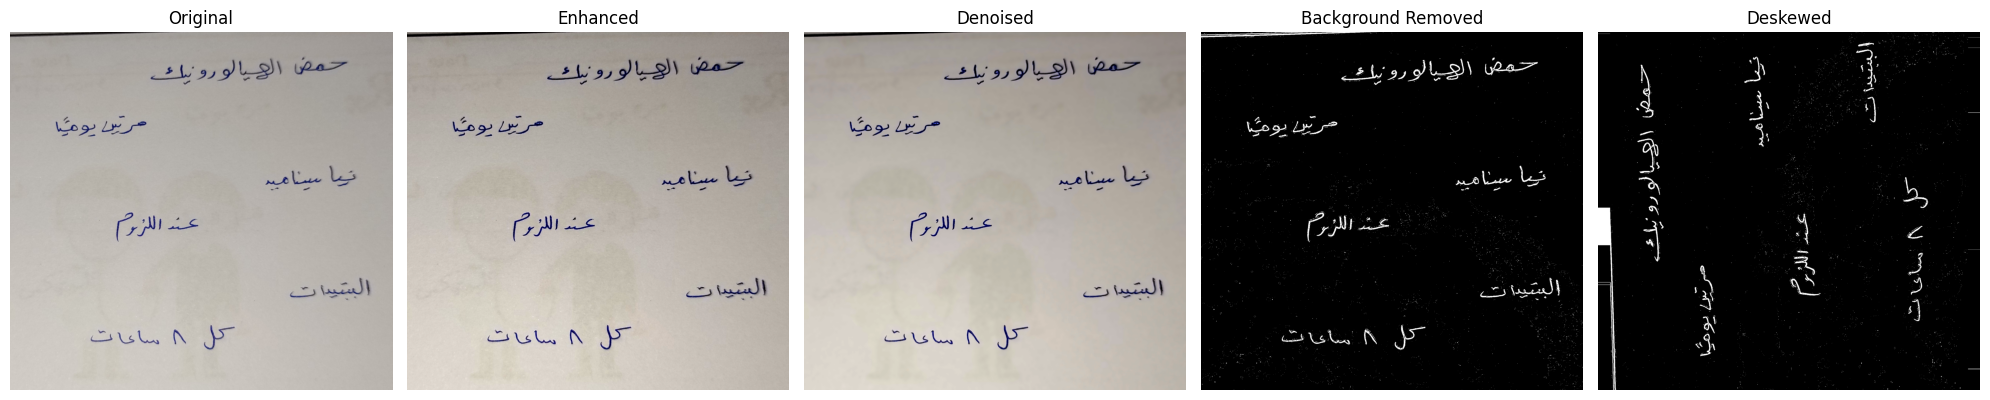

In [ ]:
from PIL import Image, ImageOps, ImageEnhance
import matplotlib.pyplot as plt
import numpy as np
def visualize_preprocessing(image_path):
    """
    Visualize the preprocessing steps
    """
    # Load original image
    original = Image.open(image_path).convert('RGB')

    # Initialize preprocessor
    preprocessor = ImagePreprocessor()

    # Apply each step
    enhanced = preprocessor.enhance_contrast(original)
    denoised = preprocessor.denoise(enhanced)
    bg_removed = preprocessor.remove_background(denoised)
    deskewed = preprocessor.deskew(bg_removed)

    # Display results
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(original)
    axes[0].set_title('Original')

    axes[1].imshow(enhanced)
    axes[1].set_title('Enhanced')

    axes[2].imshow(denoised)
    axes[2].set_title('Denoised')

    axes[3].imshow(bg_removed)
    axes[3].set_title('Background Removed')

    axes[4].imshow(deskewed)
    axes[4].set_title('Deskewed')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Usage:
visualize_preprocessing("/content/drive/MyDrive/handwritten_crops_combined/crops/crop_Beauty_prescription_10.jpg")